# Country road

Two autonomous drivers meet on a narrow road. Both go: accident (−100, −100). One stops: −1 for it, +1 for the other. Both stop: (−5, −5).

In [ ]:
#if nashpy is not installed on colab, install it with
#!pip install nashpy

In [ ]:
# !!!! ONLY ON COLAB !!!!
import sys
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')


# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/GameMatrix" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/GameMatrix'
if my_folder not in sys.path:
    sys.path.insert(0, my_folder)


if os.path.exists(my_folder):
    print(f"✅ the folder exists !")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)
    
    # On force l'insertion au tout début du path
    if my_folder not in sys.path:
        sys.path.insert(0, mon_dossier)
        
else:
    print(f"❌ folder does not exist at this path. Verify the spelling or the space.")


In [1]:
import numpy as np, nashpy as nash, matplotlib.pyplot as plt
from gtools import print_equilibria, plot_indifference

| A \ B | go | stop |
|---|---|---|
| **go** | (−100, −100) | (1, −1) |
| **stop** | (−1, 1) | (−5, −5) |

In [2]:
acts = ['go', 'stop']
A = np.array([[-100, 1], [-1, -5]])
game = nash.Game(A, A.T)   # symmetric

**Q1.** Find the Nash equilibria in pure strategies.

**Solution.** **(go, stop)** and **(stop, go)**.

**Q2.** Find the mixed-strategy equilibrium.

**Solution.** $p$ = P(A goes) makes **B** indifferent: $1 - 101p = 4p - 5 \Rightarrow p = 6/105 = 2/35 \approx 5.7\%$. Same for B.

⚠️ Equalising A's **own** payoffs gives $4/105$: wrong, the game is not zero-sum.

**Check with nashpy**

Equilibrium 1:  A -> [go: 1]   B -> [stop: 1]   payoffs = (1, -1)
Equilibrium 2:  A -> [stop: 1]   B -> [go: 1]   payoffs = (-1, 1)
Equilibrium 3:  A -> [go: 2/35, stop: 33/35]   B -> [go: 2/35, stop: 33/35]   payoffs = (-167/35, -167/35)


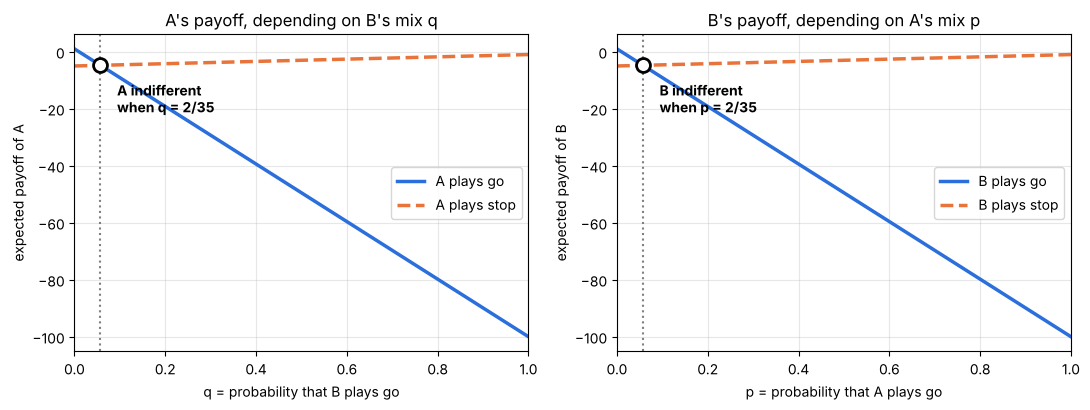

In [3]:
print_equilibria(game, acts, acts)
plot_indifference(game, acts, acts); plt.show()

**How to read the diagram.**

- **Left:** A's expected payoff for each of its two actions, depending on $q$ (how often B plays *go*).
  Where the line of an action is higher, A prefers that action. Where the two lines cross, A is **indifferent**.
- **Right:** the same for B, depending on $p$ (how often A plays *go*).

In the mixed equilibrium, each player chooses the probability that puts the **other** player exactly on the crossing point:
B plays $q$ = the crossing value of the left panel, A plays $p$ = the crossing value of the right panel.

**Q3.** What do you conclude?

**Solution.** Accident ≈ 0.3%, but both stop ≈ 89% of the time: expected payoff −4.77, almost as bad as both stopping. A shared rule (priority) is much better for autonomous vehicles.